# Naivebayes for Iris Datasets 

In [1]:
import sys
print(sys.executable)

d:\Engineering\SEM_6\Ml_lab\venv\Scripts\python.exe


In [3]:
import sklearn
import pandas
import seaborn
import matplotlib

print("Everything Working!")

Everything Working!


In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
iris=load_iris()

In [7]:
X=iris.data
y=iris.target

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [10]:
model = GaussianNB()
model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
pred=model.predict(X_test)
pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

In [ ]:
acr=accuracy_score(pred,y_test)

0.9777777777777777

In [21]:
cf=confusion_matrix(pred,y_test)

<Axes: >

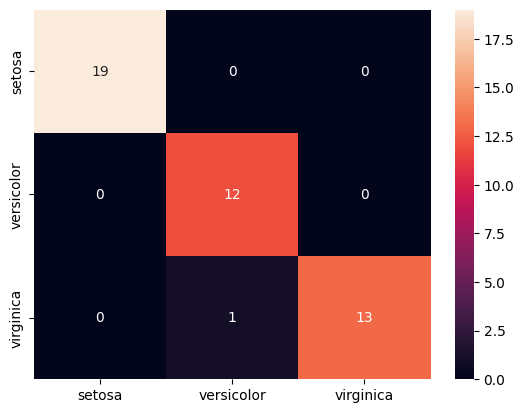

In [23]:
sns.heatmap(
    cf,
    annot=True,
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

In [29]:
classification_report(pred,y_test)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        19\n           1       0.92      1.00      0.96        12\n           2       1.00      0.93      0.96        14\n\n    accuracy                           0.98        45\n   macro avg       0.97      0.98      0.97        45\nweighted avg       0.98      0.98      0.98        45\n'

# IMDB Dataset implementation

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [32]:
df=pd.read_csv("IMDB.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [34]:
X=df['review']
y=df['sentiment'].map({'positive':1,'negative':0})

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [36]:
vectorizer=TfidfVectorizer(stop_words="english",max_features=5000)

In [38]:
X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.fit_transform(X_test)

In [ ]:
clf = MultinomialNB()

In [43]:
clf.fit(X_train_tfidf,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [50]:
prd=clf.predict(X_test_tfidf)
prd

array([1, 0, 1, ..., 1, 1, 1], shape=(12500,))

In [55]:
cm=confusion_matrix(y_test,prd)
cm

array([[2125, 4032],
       [1428, 4915]])